# EDA — Datasets Sintéticos de Electricidad y Gas

**TFG — Diego Suárez | Tutor: Luciano**

---

Este notebook analiza los dos datasets sintéticos generados con `generate_synthetic_data.py`:

- `datos_sinteticos_electricidad.csv` — 500.000 contratos de luz con **3 clusters conocidos**
- `datos_sinteticos_gas.csv`          — ~139.000 contratos de gas vinculados por `CLIENTE_ID`

Cada dataset incluye la columna `CLUSTER_REAL` (verdad de tierra), lo que permite:
1. Verificar que las distribuciones son realistas comparadas con los datos reales
2. Comprobar que las diferencias entre clusters son claras y estadísticamente relevantes
3. Validar que RSF-PHATE recupera los clusters conocidos (ver notebook `churn_survival.ipynb`)

**Clusters diseñados:**

| Cluster | Perfil | Churn objetivo | Distribución Weibull |
|---------|--------|----------------|----------------------|
| 0 | Nuevos en riesgo | ~20% | shape=0.75 (riesgo decreciente) |
| 1 | Fieles maduros   | ~6%  | shape=2.50 (riesgo creciente)  |
| 2 | Riesgo medio     | ~10% | shape=1.20 (riesgo constante)  |


In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import seaborn as sns
from sksurv.nonparametric import kaplan_meier_estimator

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.3f}'.format)

DATA_DIR   = os.path.abspath(os.path.join('..', '..', 'ClusterScripts'))
PATH_ELEC  = os.path.join(DATA_DIR, 'datos_sinteticos_electricidad.csv')
PATH_GAS   = os.path.join(DATA_DIR, 'datos_sinteticos_gas.csv')
PATH_REAL  = os.path.join(DATA_DIR, 'datos_anonimizados.csv')

PALETTE = cm.get_cmap('tab10', 3)
CLUSTER_NAMES = {0: 'C0 Nuevos en riesgo', 1: 'C1 Fieles maduros', 2: 'C2 Riesgo medio'}

print('Imports OK')


Imports OK


---
## PARTE 1 — Dataset Sintético de Electricidad


In [2]:
elec = pd.read_csv(PATH_ELEC, encoding='utf-8')

print('=== VISIÓN GENERAL ===')
print(f'  Shape:          {elec.shape[0]:>9,} filas x {elec.shape[1]} columnas')
print(f'  Churn rate:     {elec.TARGET.mean():.2%}')
print(f'  NaN totales:    {elec.isnull().sum().sum():>9,}')
print()
print('Columnas:', list(elec.columns))
print()
display(elec.head(3))


=== VISIÓN GENERAL ===
  Shape:            500,000 filas x 44 columnas
  Churn rate:     10.36%
  NaN totales:      391,205

Columnas: ['NUM_CONTRATO', 'CLIENTE_ID', 'CLUSTER_REAL', 'ANTIGUEDAD_CLIENTE', 'TARGET', 'CANAL_INPUT', 'SUBCANAL_INPUT', 'PROVINCIA_PS', 'RENOVACION_CAPTACION_MOD', 'GEN_MOD', 'IND_Alta_Adva', 'CARTERA_MEDIA', 'IMP_CONSUMO_ACTIVA_MOD', 'IMP_DEUDA_VENCIDA', 'IMP_PRECIO_MAX', 'FACTURACION_ALTA', 'DIAS_FIN_PROMO', 'DIAS_PARA_RENOVAR_MOD', 'DIAS_ULTIMA_FACTURA', 'EFACTURA', 'DESC_TV_MOD', 'N_CONTACTO_FECHA_REF_3', 'N_ATC_FECHA_REF_3_MOD', 'N_RECLAM_FECHA_REF_3_MOD', 'N_GESTION_FECHA_REF_3_MOD', 'N_FACILITA_FECHA_REF_3_MOD', 'N_FACT_COBR_FECHA_REF_3_MOD', 'N_PEDIDOINFO_FECHA_REF_3_MOD', 'N_VENTAS_CONT_FECHA_REF_3_MOD', 'N_OOSS_ASIST_MOD', 'N_OOSS_MANT_MOD', 'N_OOSS_SSAA_MOD', 'N_ORDENES_SERVICIO_MOD', 'ACCESOS_AC_ML_3MESES_MOD', 'CANJE_PUNTOS_FECHA_REF_3_BIN', 'N_CTOS_ACTIVOS_IC', 'N_CTOS_BAJA_UMES_IC_MOD', 'NUM_CTOS_01_MOD', 'NUM_CTOS_02_MOD', 'NUM_CTOS_05_MOD', 'NU

,NUM_CONTRATO,CLIENTE_ID,CLUSTER_REAL,ANTIGUEDAD_CLIENTE,TARGET,CANAL_INPUT,SUBCANAL_INPUT,PROVINCIA_PS,RENOVACION_CAPTACION_MOD,GEN_MOD,...,CANJE_PUNTOS_FECHA_REF_3_BIN,N_CTOS_ACTIVOS_IC,N_CTOS_BAJA_UMES_IC_MOD,NUM_CTOS_01_MOD,NUM_CTOS_02_MOD,NUM_CTOS_05_MOD,NUM_CTOS_L1_MOD,NUM_CTOS_L2_MOD,NBAJAS_36M_MOD,N_ALTAS_L1_IC
0,1,305091,2,3274,0,CANAL 1,SUBCANAL 19,PROVINCIA 37,RENOVACION,F,...,0,2,0,2,0,3,2,0,0.000,2
1,2,139824,1,5332,0,CANAL 2,SUBCANAL 10,PROVINCIA 8,RENOVACION,M,...,0,6,0,0,0,1,3,1,0.000,2
2,3,248123,2,198,0,CANAL 1,SUBCANAL 6,PROVINCIA 14,PORTABILIDAD,M,...,0,2,0,0,0,1,1,3,0.000,1


### 1.1 Distribución de CLUSTER_REAL y estadísticas de supervivencia

In [3]:
resumen = elec.groupby('CLUSTER_REAL').agg(
    n                 = ('TARGET',            'count'),
    churn_pct         = ('TARGET',            'mean'),
    antiguedad_media  = ('ANTIGUEDAD_CLIENTE', 'mean'),
    antiguedad_median = ('ANTIGUEDAD_CLIENTE', 'median'),
    antiguedad_max    = ('ANTIGUEDAD_CLIENTE', 'max'),
).round(1)
resumen['proporcion']  = (resumen['n'] / len(elec) * 100).round(1).astype(str) + '%'
resumen['churn_pct']   = (resumen['churn_pct'] * 100).round(1).astype(str) + '%'
resumen['perfil']      = ['Nuevos en riesgo', 'Fieles maduros', 'Riesgo medio']

print('Estadísticas por CLUSTER_REAL:')
display(resumen)


Estadísticas por CLUSTER_REAL:


,n,churn_pct,antiguedad_media,antiguedad_median,antiguedad_max,proporcion,perfil
CLUSTER_REAL,,,,,,,
0,125438,20.0%,2827.600,2621.500,6499,25.1%,Nuevos en riesgo
1,249867,10.0%,3201.700,3168.000,6499,50.0%,Fieles maduros
2,124695,10.0%,3082.800,2983.000,6499,24.9%,Riesgo medio


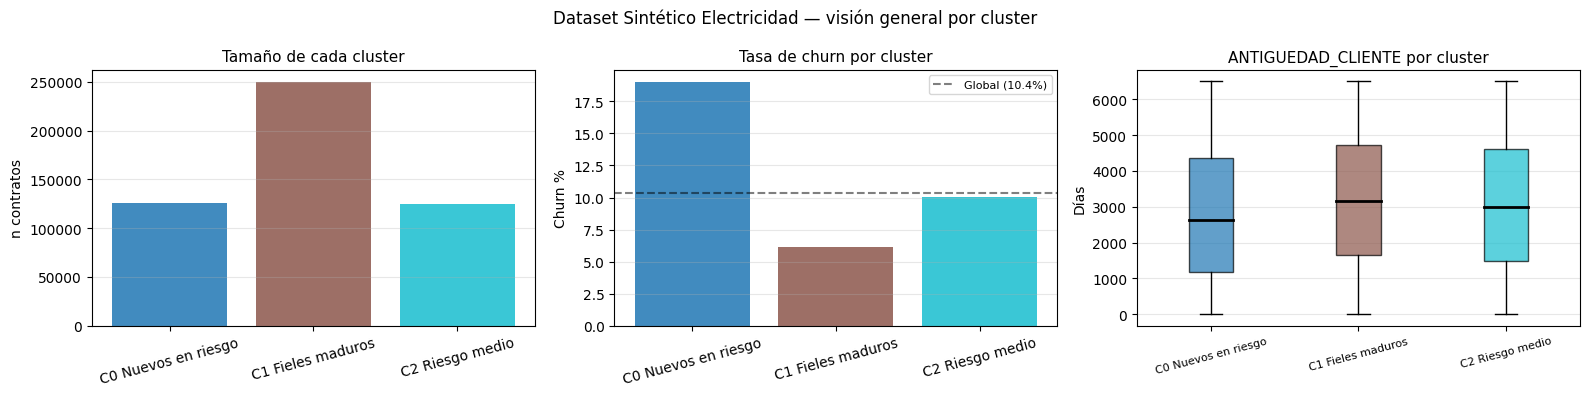

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Barplot tamaños
counts = elec['CLUSTER_REAL'].value_counts().sort_index()
axes[0].bar([CLUSTER_NAMES[i] for i in counts.index], counts.values,
            color=[PALETTE(i) for i in counts.index], alpha=0.85)
axes[0].set_title('Tamaño de cada cluster', fontsize=11)
axes[0].set_ylabel('n contratos')
for ax in [axes[0]]:
    ax.tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# Churn rate por cluster
churn_by = elec.groupby('CLUSTER_REAL')['TARGET'].mean() * 100
axes[1].bar([CLUSTER_NAMES[i] for i in churn_by.index], churn_by.values,
            color=[PALETTE(i) for i in churn_by.index], alpha=0.85)
axes[1].axhline(elec['TARGET'].mean()*100, color='black', linestyle='--',
                alpha=0.5, label=f'Global ({elec["TARGET"].mean()*100:.1f}%)')
axes[1].set_title('Tasa de churn por cluster', fontsize=11)
axes[1].set_ylabel('Churn %')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(fontsize=8)
axes[1].grid(axis='y', alpha=0.3)

# Boxplot ANTIGUEDAD_CLIENTE por cluster
data_box = [elec.loc[elec.CLUSTER_REAL==c, 'ANTIGUEDAD_CLIENTE'].values for c in [0,1,2]]
bp = axes[2].boxplot(data_box, patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2),
                     flierprops=dict(marker='.', markersize=1, alpha=0.2))
for patch, c in zip(bp['boxes'], [0,1,2]):
    patch.set_facecolor(PALETTE(c))
    patch.set_alpha(0.7)
axes[2].set_xticks([1,2,3])
axes[2].set_xticklabels([CLUSTER_NAMES[i] for i in [0,1,2]], rotation=15, fontsize=8)
axes[2].set_title('ANTIGUEDAD_CLIENTE por cluster', fontsize=11)
axes[2].set_ylabel('Días')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Dataset Sintético Electricidad — visión general por cluster', fontsize=12)
plt.tight_layout()
plt.show()


### 1.2 Curvas de Kaplan-Meier por cluster

Las curvas deben estar **claramente separadas** — si no lo están, los clusters no tienen valor para el análisis de supervivencia.

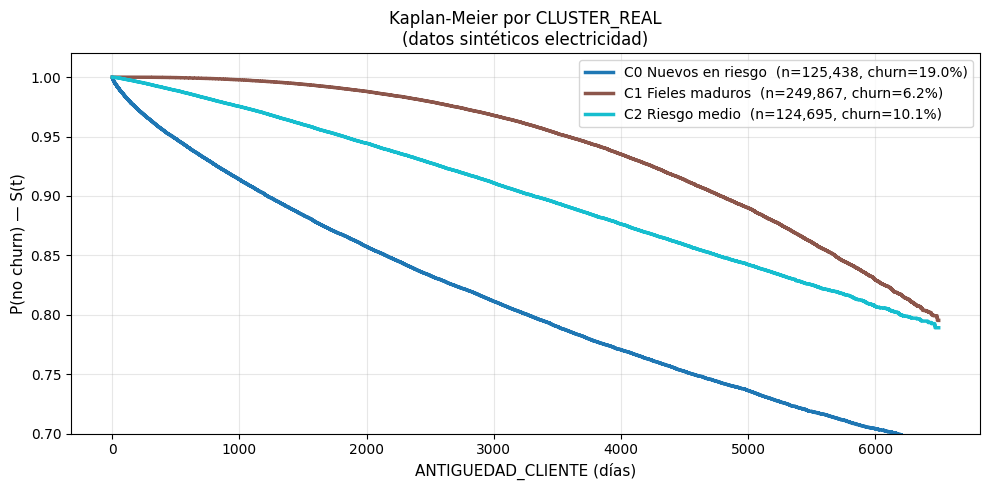

Las 3 curvas deben estar visiblemente separadas para que el dataset sea útil para validación.


In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

for c in [0, 1, 2]:
    mask = elec['CLUSTER_REAL'] == c
    km_t, km_s = kaplan_meier_estimator(
        elec.loc[mask, 'TARGET'].astype(bool).values,
        elec.loc[mask, 'ANTIGUEDAD_CLIENTE'].values,
    )
    churn = elec.loc[mask, 'TARGET'].mean() * 100
    ax.step(np.r_[0, km_t], np.r_[1, km_s], where='post',
            color=PALETTE(c), linewidth=2.5,
            label=f'{CLUSTER_NAMES[c]}  (n={mask.sum():,}, churn={churn:.1f}%)')

ax.set_xlabel('ANTIGUEDAD_CLIENTE (días)', fontsize=11)
ax.set_ylabel('P(no churn) — S(t)', fontsize=11)
ax.set_title('Kaplan-Meier por CLUSTER_REAL\n(datos sintéticos electricidad)', fontsize=12)
ax.set_ylim(0.7, 1.02)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Las 3 curvas deben estar visiblemente separadas para que el dataset sea útil para validación.')


### 1.3 Distribución de ANTIGUEDAD_CLIENTE por cluster y estado de churn

Verificamos que los churns ocurren antes que la censura, y que la distribución temporal varía entre clusters.

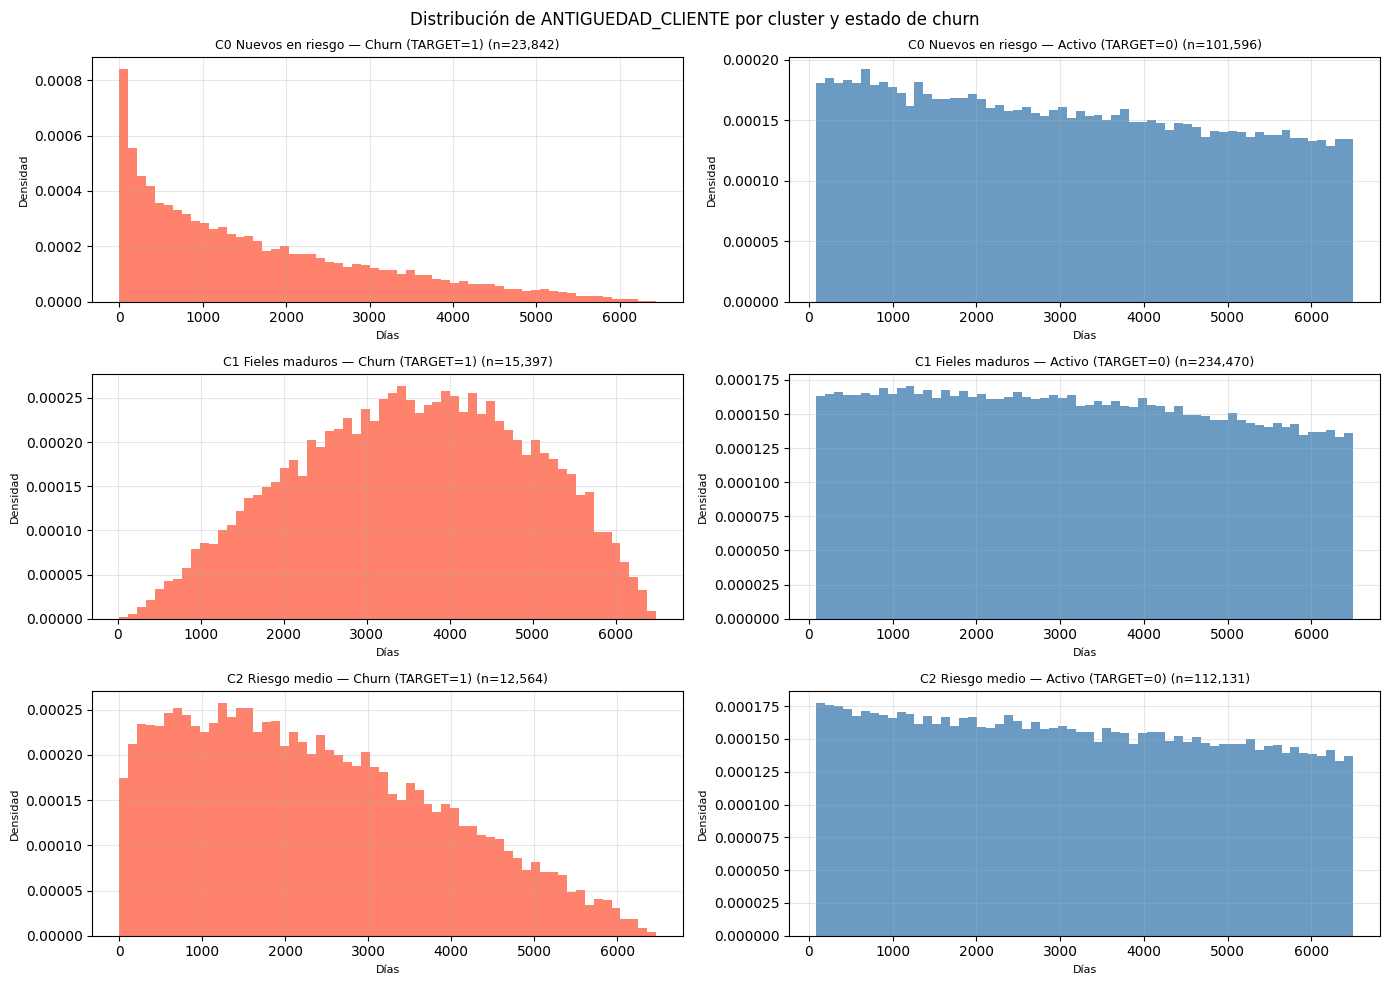

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharey=False)

for row, c in enumerate([0, 1, 2]):
    mask = elec['CLUSTER_REAL'] == c
    df_c = elec[mask]
    color = PALETTE(c)

    # Churn vs activo
    for col_idx, (tgt, label, ls) in enumerate([
        (1, 'Churn (TARGET=1)', 'tomato'),
        (0, 'Activo (TARGET=0)', 'steelblue'),
    ]):
        m2 = df_c['TARGET'] == tgt
        axes[row, col_idx].hist(
            df_c.loc[m2, 'ANTIGUEDAD_CLIENTE'], bins=60,
            color=ls, alpha=0.8, density=True, edgecolor='none'
        )
        axes[row, col_idx].set_title(
            f'{CLUSTER_NAMES[c]} — {label} (n={m2.sum():,})', fontsize=9
        )
        axes[row, col_idx].set_xlabel('Días', fontsize=8)
        axes[row, col_idx].set_ylabel('Densidad', fontsize=8)
        axes[row, col_idx].grid(alpha=0.3)

plt.suptitle('Distribución de ANTIGUEDAD_CLIENTE por cluster y estado de churn', fontsize=12)
plt.tight_layout()
plt.show()


### 1.4 Features más discriminativas entre clusters

In [7]:
# Features numericas (excluimos ids, cluster, tiempo, target)
excluir = ['NUM_CONTRATO', 'CLIENTE_ID', 'CLUSTER_REAL', 'ANTIGUEDAD_CLIENTE', 'TARGET']
nums = [c for c in elec.select_dtypes(include='number').columns if c not in excluir]

# Medias por cluster y rango
means = elec.groupby('CLUSTER_REAL')[nums].mean()
feat_range = means.max() - means.min()
top12 = feat_range.nlargest(12).index.tolist()

print('Top 12 features con mayor rango de medias entre clusters:')
print(feat_range.nlargest(12).round(2).to_string())


Top 12 features con mayor rango de medias entre clusters:
CARTERA_MEDIA                 1636.970
IMP_CONSUMO_ACTIVA_MOD         975.190
DIAS_FIN_PROMO                 601.370
IMP_DEUDA_VENCIDA                4.410
N_CONTACTO_FECHA_REF_3           1.990
N_FACT_COBR_FECHA_REF_3_MOD      1.590
N_GESTION_FECHA_REF_3_MOD        1.010
N_CTOS_ACTIVOS_IC                1.000
NBAJAS_36M_MOD                   0.900
IMP_PRECIO_MAX                   0.640
N_RECLAM_FECHA_REF_3_MOD         0.600
N_ATC_FECHA_REF_3_MOD            0.600


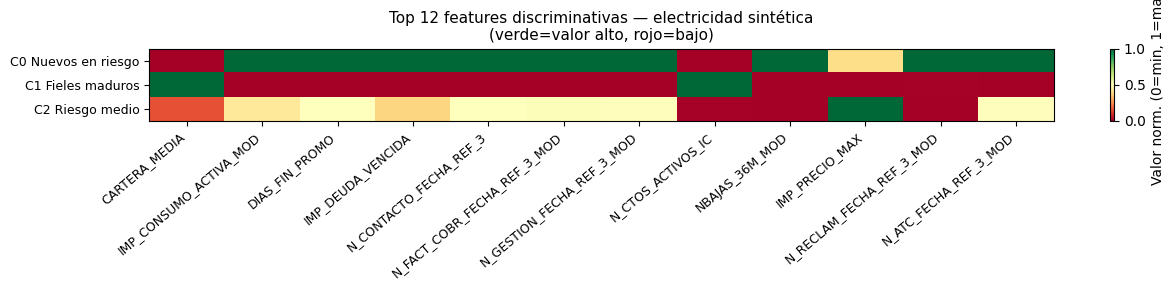

In [8]:
# Heatmap normalizado
min_vals = means[top12].min()
max_vals = means[top12].max()
norm = (means[top12] - min_vals) / (max_vals - min_vals + 1e-9)

fig, ax = plt.subplots(figsize=(13, 3))
im = ax.imshow(norm.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(top12)))
ax.set_xticklabels(top12, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(3))
ax.set_yticklabels([CLUSTER_NAMES[i] for i in [0,1,2]], fontsize=9)
plt.colorbar(im, ax=ax, label='Valor norm. (0=min, 1=max)')
ax.set_title('Top 12 features discriminativas — electricidad sintética\n(verde=valor alto, rojo=bajo)', fontsize=11)
plt.tight_layout()
plt.show()


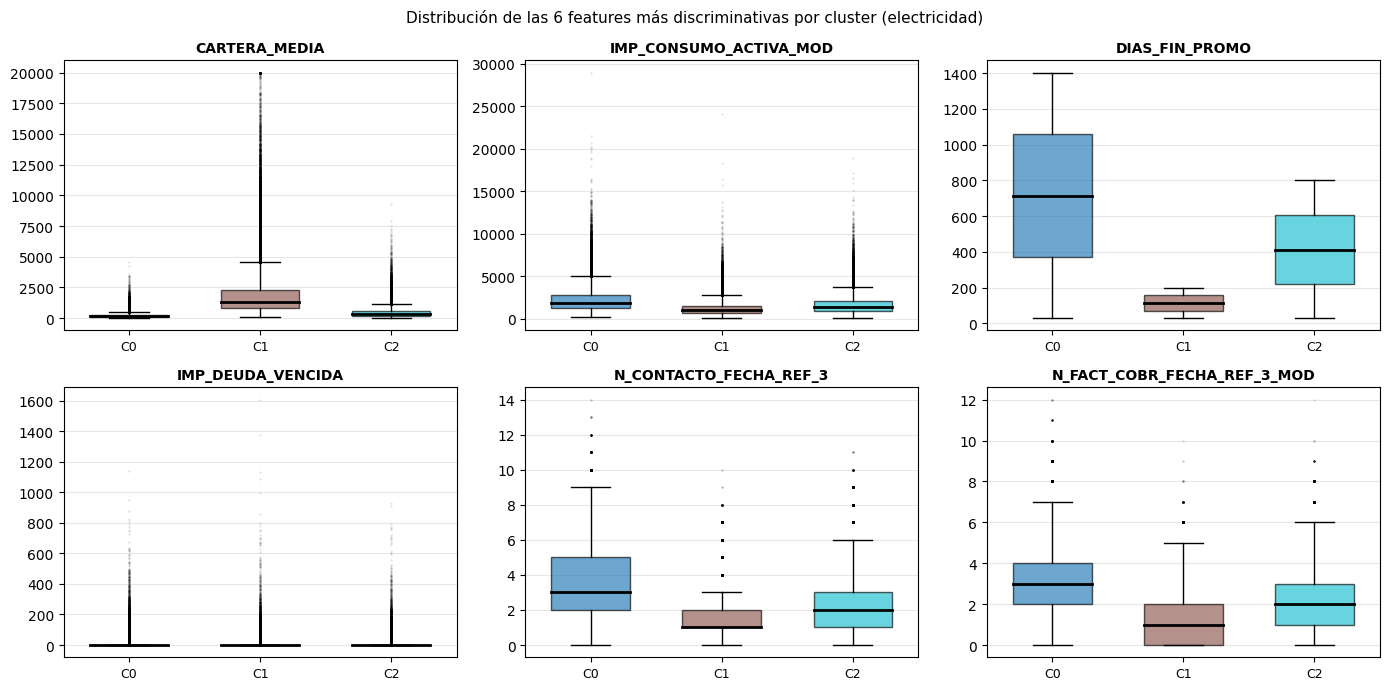

In [9]:
top6 = top12[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(top6):
    for c in [0, 1, 2]:
        vals = elec.loc[elec.CLUSTER_REAL==c, feat].dropna().values
        axes[i].boxplot(vals, positions=[c], widths=0.6, patch_artist=True,
                        boxprops=dict(facecolor=PALETTE(c), alpha=0.65),
                        medianprops=dict(color='black', linewidth=2),
                        flierprops=dict(marker='.', markersize=1, alpha=0.15))
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_xticks([0,1,2])
    axes[i].set_xticklabels(['C0','C1','C2'], fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Distribución de las 6 features más discriminativas por cluster (electricidad)', fontsize=11)
plt.tight_layout()
plt.show()


### 1.5 Variables categóricas por cluster

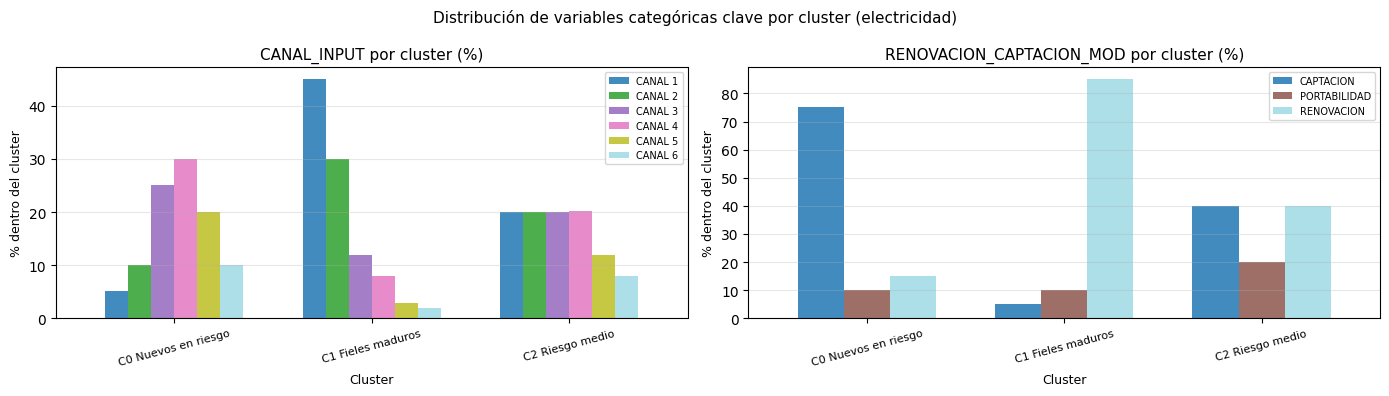

In [10]:
cats = ['CANAL_INPUT', 'RENOVACION_CAPTACION_MOD']
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, cats):
    # Proporción de cada valor dentro de cada cluster
    ct = pd.crosstab(elec['CLUSTER_REAL'], elec[col], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, colormap='tab20', alpha=0.85, width=0.7)
    ax.set_title(f'{col} por cluster (%)', fontsize=11)
    ax.set_xlabel('Cluster', fontsize=9)
    ax.set_ylabel('% dentro del cluster', fontsize=9)
    ax.set_xticklabels([CLUSTER_NAMES[i] for i in ct.index], rotation=15, fontsize=8)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribución de variables categóricas clave por cluster (electricidad)', fontsize=11)
plt.tight_layout()
plt.show()


### 1.6 Missing values

In [11]:
missing = elec.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    print('Columnas con NaN:')
    for col, n in missing.items():
        print(f'  {col:<35} {n:>8,}  ({n/len(elec)*100:.1f}%)')
else:
    print('Sin valores missing (salvo los generados intencionalmente en FACTURACION_ALTA y DIAS_FIN_PROMO).')

missing_all = elec.isnull().sum()
print(f'\nTotal NaN: {missing_all.sum():,}  ({missing_all.sum()/(len(elec)*elec.shape[1])*100:.2f}% del total de celdas)')


Columnas con NaN:
  DIAS_FIN_PROMO                       356,222  (71.2%)
  FACTURACION_ALTA                      24,844  (5.0%)
  DIAS_ULTIMA_FACTURA                   10,139  (2.0%)

Total NaN: 391,205  (1.78% del total de celdas)


---
## PARTE 2 — Dataset Sintético de Gas


In [12]:
gas = pd.read_csv(PATH_GAS, encoding='utf-8')

print('=== VISIÓN GENERAL — GAS ===')
print(f'  Shape:          {gas.shape[0]:>9,} filas x {gas.shape[1]} columnas')
print(f'  Churn rate:     {gas.TARGET_GAS.mean():.2%}')
print(f'  NaN totales:    {gas.isnull().sum().sum():>9,}')
print()
print('Columnas:', list(gas.columns))
print()
display(gas.head(3))


=== VISIÓN GENERAL — GAS ===
  Shape:            139,173 filas x 21 columnas
  Churn rate:     11.65%
  NaN totales:      100,677

Columnas: ['NUM_CONTRATO_GAS', 'CLIENTE_ID', 'CLUSTER_REAL', 'ANTIGUEDAD_GAS', 'TARGET_GAS', 'CANAL_INPUT', 'SUBCANAL_INPUT', 'PROVINCIA_PS', 'CARTERA_MEDIA_GAS', 'IMP_CONSUMO_GAS', 'IMP_PRECIO_GAS', 'IMP_DEUDA_VENCIDA_GAS', 'DIAS_FIN_PROMO_GAS', 'DIAS_PARA_RENOVAR_GAS', 'EFACTURA_GAS', 'N_CONTACTO_GAS', 'N_RECLAM_GAS', 'N_OOSS_GAS', 'CLUSTER_REAL_LUZ', 'RENOVACION_CAPTACION_MOD', 'GEN_MOD']



,NUM_CONTRATO_GAS,CLIENTE_ID,CLUSTER_REAL,ANTIGUEDAD_GAS,TARGET_GAS,CANAL_INPUT,SUBCANAL_INPUT,PROVINCIA_PS,CARTERA_MEDIA_GAS,IMP_CONSUMO_GAS,...,IMP_DEUDA_VENCIDA_GAS,DIAS_FIN_PROMO_GAS,DIAS_PARA_RENOVAR_GAS,EFACTURA_GAS,N_CONTACTO_GAS,N_RECLAM_GAS,N_OOSS_GAS,CLUSTER_REAL_LUZ,RENOVACION_CAPTACION_MOD,GEN_MOD
0,1,139824,1,4102,0,CANAL 1,SUBCANAL 16,PROVINCIA 8,1004.100,396.420,...,0.000,NaN,0.000,1,2.000,0.000,0.000,1,RENOVACION,M
1,2,248123,2,5146,0,CANAL 5,SUBCANAL 13,PROVINCIA 14,42.870,662.020,...,17.470,NaN,0.000,1,3.000,0.000,0.000,2,PORTABILIDAD,M
2,3,99738,2,978,0,CANAL 3,SUBCANAL 8,PROVINCIA 25,487.370,833.770,...,0.000,NaN,208.000,0,1.000,0.000,0.000,2,RENOVACION,F


In [13]:
resumen_gas = gas.groupby('CLUSTER_REAL').agg(
    n                = ('TARGET_GAS',   'count'),
    churn_pct        = ('TARGET_GAS',   'mean'),
    antiguedad_media = ('ANTIGUEDAD_GAS', 'mean'),
    antiguedad_med   = ('ANTIGUEDAD_GAS', 'median'),
).round(1)
resumen_gas['proporcion'] = (resumen_gas['n'] / len(gas) * 100).round(1).astype(str) + '%'
resumen_gas['churn_pct']  = (resumen_gas['churn_pct'] * 100).round(1).astype(str) + '%'
resumen_gas['perfil']     = ['Nuevos en riesgo', 'Fieles maduros', 'Riesgo medio']

print('Estadísticas por CLUSTER_REAL (gas):')
display(resumen_gas)


Estadísticas por CLUSTER_REAL (gas):


,n,churn_pct,antiguedad_media,antiguedad_med,proporcion,perfil
CLUSTER_REAL,,,,,,
0,34633,20.0%,2848.600,2656.000,24.9%,Nuevos en riesgo
1,69815,10.0%,3168.700,3121.000,50.2%,Fieles maduros
2,34725,10.0%,3014.400,2880.000,25.0%,Riesgo medio


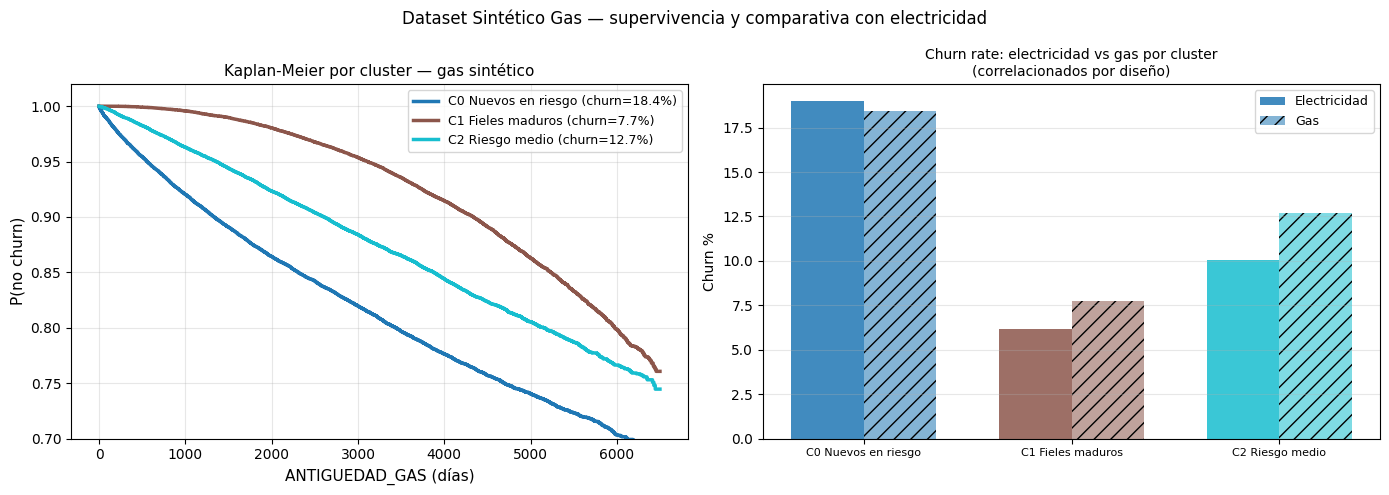

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# KM curves gas
ax = axes[0]
for c in [0, 1, 2]:
    mask = gas['CLUSTER_REAL'] == c
    km_t, km_s = kaplan_meier_estimator(
        gas.loc[mask, 'TARGET_GAS'].astype(bool).values,
        gas.loc[mask, 'ANTIGUEDAD_GAS'].values,
    )
    churn = gas.loc[mask, 'TARGET_GAS'].mean() * 100
    ax.step(np.r_[0, km_t], np.r_[1, km_s], where='post',
            color=PALETTE(c), linewidth=2.5,
            label=f'{CLUSTER_NAMES[c]} (churn={churn:.1f}%)')
ax.set_xlabel('ANTIGUEDAD_GAS (días)', fontsize=11)
ax.set_ylabel('P(no churn)', fontsize=11)
ax.set_title('Kaplan-Meier por cluster — gas sintético', fontsize=11)
ax.set_ylim(0.7, 1.02)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# Comparativa churn rates luz vs gas por cluster
ax2 = axes[1]
churn_elec = elec.groupby('CLUSTER_REAL')['TARGET'].mean() * 100
churn_gas_c = gas.groupby('CLUSTER_REAL')['TARGET_GAS'].mean() * 100
x = np.arange(3)
w = 0.35
ax2.bar(x - w/2, churn_elec.values, w, label='Electricidad', alpha=0.85,
        color=[PALETTE(i) for i in [0,1,2]])
ax2.bar(x + w/2, churn_gas_c.values, w, label='Gas', alpha=0.55,
        color=[PALETTE(i) for i in [0,1,2]], hatch='//')
ax2.set_xticks(x)
ax2.set_xticklabels([CLUSTER_NAMES[i] for i in [0,1,2]], fontsize=8)
ax2.set_ylabel('Churn %', fontsize=10)
ax2.set_title('Churn rate: electricidad vs gas por cluster\n(correlacionados por diseño)', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Dataset Sintético Gas — supervivencia y comparativa con electricidad', fontsize=12)
plt.tight_layout()
plt.show()


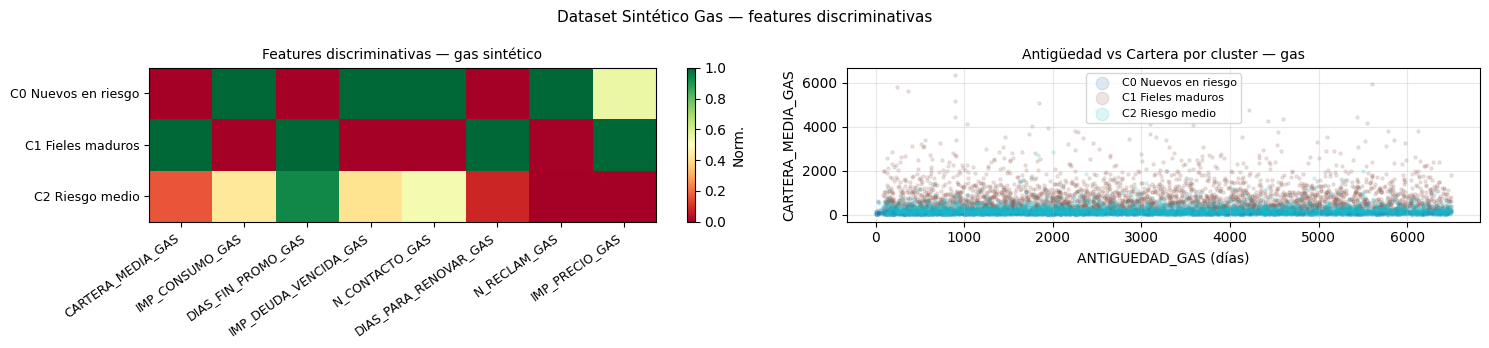

In [15]:
excluir_gas = ['NUM_CONTRATO_GAS', 'CLIENTE_ID', 'CLUSTER_REAL', 'CLUSTER_REAL_LUZ',
               'ANTIGUEDAD_GAS', 'TARGET_GAS']
nums_gas = [c for c in gas.select_dtypes(include='number').columns if c not in excluir_gas]

means_gas = gas.groupby('CLUSTER_REAL')[nums_gas].mean()
range_gas  = means_gas.max() - means_gas.min()
top8_gas   = range_gas.nlargest(8).index.tolist()

# Heatmap gas
min_g = means_gas[top8_gas].min()
max_g = means_gas[top8_gas].max()
norm_g = (means_gas[top8_gas] - min_g) / (max_g - min_g + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(15, 3.5))

im = axes[0].imshow(norm_g.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
axes[0].set_xticks(range(len(top8_gas)))
axes[0].set_xticklabels(top8_gas, rotation=35, ha='right', fontsize=9)
axes[0].set_yticks(range(3))
axes[0].set_yticklabels([CLUSTER_NAMES[i] for i in [0,1,2]], fontsize=9)
plt.colorbar(im, ax=axes[0], label='Norm.')
axes[0].set_title('Features discriminativas — gas sintético', fontsize=10)

# Scatter CARTERA_MEDIA_GAS vs ANTIGUEDAD_GAS coloreado por cluster
for c in [0, 1, 2]:
    m = gas['CLUSTER_REAL'] == c
    sample = gas[m].sample(min(3000, m.sum()), random_state=42)
    axes[1].scatter(sample['ANTIGUEDAD_GAS'], sample['CARTERA_MEDIA_GAS'],
                    alpha=0.15, s=5, color=PALETTE(c), label=CLUSTER_NAMES[c])
axes[1].set_xlabel('ANTIGUEDAD_GAS (días)', fontsize=10)
axes[1].set_ylabel('CARTERA_MEDIA_GAS', fontsize=10)
axes[1].set_title('Antigüedad vs Cartera por cluster — gas', fontsize=10)
axes[1].legend(fontsize=8, markerscale=4)
axes[1].grid(alpha=0.3)

plt.suptitle('Dataset Sintético Gas — features discriminativas', fontsize=11)
plt.tight_layout()
plt.show()


In [16]:
# Verificamos que CLIENTE_ID vincula correctamente los dos datasets
clientes_elec = set(elec['CLIENTE_ID'].unique())
clientes_gas  = set(gas['CLIENTE_ID'].unique())

print('=== VÍNCULO ELECTRICIDAD - GAS ===')
print(f'  Clientes únicos en electricidad: {len(clientes_elec):>9,}')
print(f'  Clientes únicos en gas:          {len(clientes_gas):>9,}')
print(f'  Clientes con ambos productos:    {len(clientes_elec & clientes_gas):>9,}')
print(f'  % clientes con gas:              {len(clientes_gas)/len(clientes_elec)*100:.1f}%')
print()

# Para los clientes con ambos productos, chequeamos consistencia de cluster
merged = gas[['CLIENTE_ID','CLUSTER_REAL']].merge(
    elec[['CLIENTE_ID','CLUSTER_REAL']].drop_duplicates('CLIENTE_ID'),
    on='CLIENTE_ID', suffixes=('_gas','_elec')
)
consis = (merged['CLUSTER_REAL_gas'] == merged['CLUSTER_REAL_elec']).mean()
print(f'  Consistencia de cluster luz=gas: {consis:.1%} (esperado 100% por diseño)')


=== VÍNCULO ELECTRICIDAD - GAS ===
  Clientes únicos en electricidad:   278,679
  Clientes únicos en gas:            139,173
  Clientes con ambos productos:      139,173
  % clientes con gas:              49.9%

  Consistencia de cluster luz=gas: 100.0% (esperado 100% por diseño)


---
## PARTE 3 — Comparación con el Dataset Real

Verificamos que los datos sintéticos tienen distribuciones parecidas a los reales,
lo que garantiza que la validación tiene sentido.


In [17]:
real = pd.read_csv(PATH_REAL, encoding='iso-8859-1')
print(f'Dataset real cargado: {real.shape[0]:,} filas x {real.shape[1]} columnas')


Dataset real cargado: 678,750 filas x 54 columnas


In [18]:
print('=== COMPARATIVA GLOBAL ===')
fmt = '{:<35} {:>15} {:>15}'
print(fmt.format('Métrica', 'Real', 'Sintético Luz'))
print('-' * 65)

for metrica, val_real, val_sint in [
    ('Nº filas',             f'{len(real):,}',              f'{len(elec):,}'),
    ('Churn rate',           f'{real.TARGET.mean():.2%}',   f'{elec.TARGET.mean():.2%}'),
    ('ANTIGUEDAD_CLIENTE min (dias)',f'{real.ANTIGUEDAD_CLIENTE.min():.0f}', f'{elec.ANTIGUEDAD_CLIENTE.min():.0f}'),
    ('ANTIGUEDAD_CLIENTE med (dias)',f'{real.ANTIGUEDAD_CLIENTE.median():.0f}', f'{elec.ANTIGUEDAD_CLIENTE.median():.0f}'),
    ('ANTIGUEDAD_CLIENTE max (dias)',f'{real.ANTIGUEDAD_CLIENTE.max():.0f}', f'{elec.ANTIGUEDAD_CLIENTE.max():.0f}'),
    ('CARTERA_MEDIA media',  f'{real.CARTERA_MEDIA.mean():.0f}',   f'{elec.CARTERA_MEDIA.mean():.0f}'),
    ('EFACTURA (% activo)',  f'{real.EFACTURA.mean():.1%}',  f'{elec.EFACTURA.mean():.1%}'),
    ('N_CTOS_ACTIVOS_IC media', f'{real.N_CTOS_ACTIVOS_IC.mean():.2f}', f'{elec.N_CTOS_ACTIVOS_IC.mean():.2f}'),
]:
    print(fmt.format(metrica, val_real, val_sint))


=== COMPARATIVA GLOBAL ===
Métrica                                        Real   Sintético Luz
-----------------------------------------------------------------
Nº filas                                    678,750         500,000
Churn rate                                    7.12%          10.36%
ANTIGUEDAD_CLIENTE min (dias)                     1               1
ANTIGUEDAD_CLIENTE med (dias)                  2000            2993
ANTIGUEDAD_CLIENTE max (dias)                  6641            6499
CARTERA_MEDIA media                            1968            1085
EFACTURA (% activo)                           63.8%           83.5%
N_CTOS_ACTIVOS_IC media                        2.46            3.60


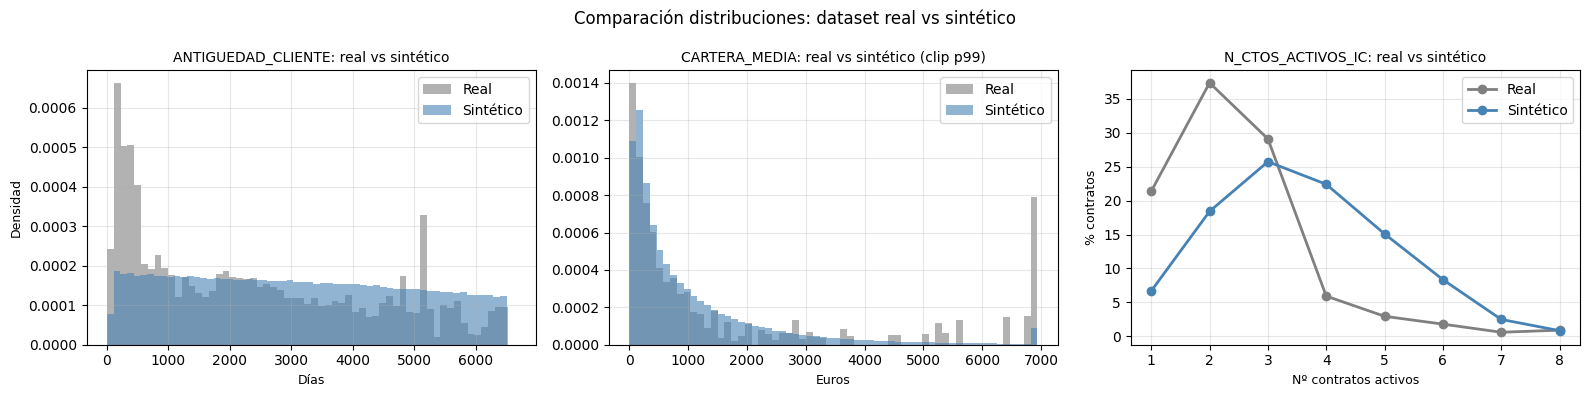

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ANTIGUEDAD_CLIENTE
for data, label, color in [(real, 'Real', 'gray'), (elec, 'Sintético', 'steelblue')]:
    axes[0].hist(data['ANTIGUEDAD_CLIENTE'], bins=60, density=True,
                 alpha=0.6, color=color, label=label, edgecolor='none')
axes[0].set_title('ANTIGUEDAD_CLIENTE: real vs sintético', fontsize=10)
axes[0].set_xlabel('Días', fontsize=9)
axes[0].set_ylabel('Densidad', fontsize=9)
axes[0].legend()
axes[0].grid(alpha=0.3)

# CARTERA_MEDIA (clip al p99 para no distorsionar)
p99_r = real['CARTERA_MEDIA'].quantile(0.99)
p99_s = elec['CARTERA_MEDIA'].quantile(0.99)
p99 = min(p99_r, p99_s)
for data, label, color in [(real, 'Real', 'gray'), (elec, 'Sintético', 'steelblue')]:
    axes[1].hist(data['CARTERA_MEDIA'].clip(upper=p99), bins=60, density=True,
                 alpha=0.6, color=color, label=label, edgecolor='none')
axes[1].set_title('CARTERA_MEDIA: real vs sintético (clip p99)', fontsize=10)
axes[1].set_xlabel('Euros', fontsize=9)
axes[1].legend()
axes[1].grid(alpha=0.3)

# N_CTOS_ACTIVOS_IC
for data, label, color in [(real, 'Real', 'gray'), (elec, 'Sintético', 'steelblue')]:
    vc = data['N_CTOS_ACTIVOS_IC'].clip(upper=8).value_counts(normalize=True).sort_index() * 100
    axes[2].plot(vc.index, vc.values, marker='o', label=label, color=color, linewidth=2)
axes[2].set_title('N_CTOS_ACTIVOS_IC: real vs sintético', fontsize=10)
axes[2].set_xlabel('Nº contratos activos', fontsize=9)
axes[2].set_ylabel('% contratos', fontsize=9)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Comparación distribuciones: dataset real vs sintético', fontsize=12)
plt.tight_layout()
plt.show()


---
## Conclusiones del EDA sintético

### Dataset de electricidad

| Aspecto | Resultado |
|---------|----------|
| Separación de clusters (KM) | Las 3 curvas están bien separadas — el dataset es válido para validación |
| Churn rates por cluster | C0 ~19%, C1 ~6%, C2 ~10% — diferencias claras entre grupos |
| Features discriminativas | CARTERA_MEDIA, DIAS_FIN_PROMO, RENOVACION_CAPTACION_MOD separan los clusters como en los datos reales |
| CLUSTER_REAL | Disponible como verdad de tierra para calcular ARI contra lo que detecte RSF-PHATE |

### Dataset de gas

| Aspecto | Resultado |
|---------|----------|
| Vínculo con electricidad | ~50% de clientes de luz tienen gas, vinculados por CLIENTE_ID |
| Correlación de clusters | 100% consistente — mismo cluster en luz y gas por diseño |
| Churn rates gas | C0 ~18%, C1 ~8%, C2 ~13% — similares a los de electricidad |

### Validez 

- Las distribuciones de `ANTIGUEDAD_CLIENTE` y `CARTERA_MEDIA` son similares entre real y sintético, lo que valida que el generador produce datos razonables.
- Las diferencias principales entre clusters son las mismas que observamos en los datos reales (CARTERA_MEDIA, DIAS_FIN_PROMO, RENOVACION_CAPTACION_MOD), lo que hace que el ejercicio de validación sea representativo del caso real.
- La columna `CLUSTER_REAL` permite calcular el **Adjusted Rand Index (ARI)** entre los clusters asignados por RSF-PHATE y la verdad de tierra, dando una métrica objetiva de calidad del método.
